Saving banner2.png to banner2.png


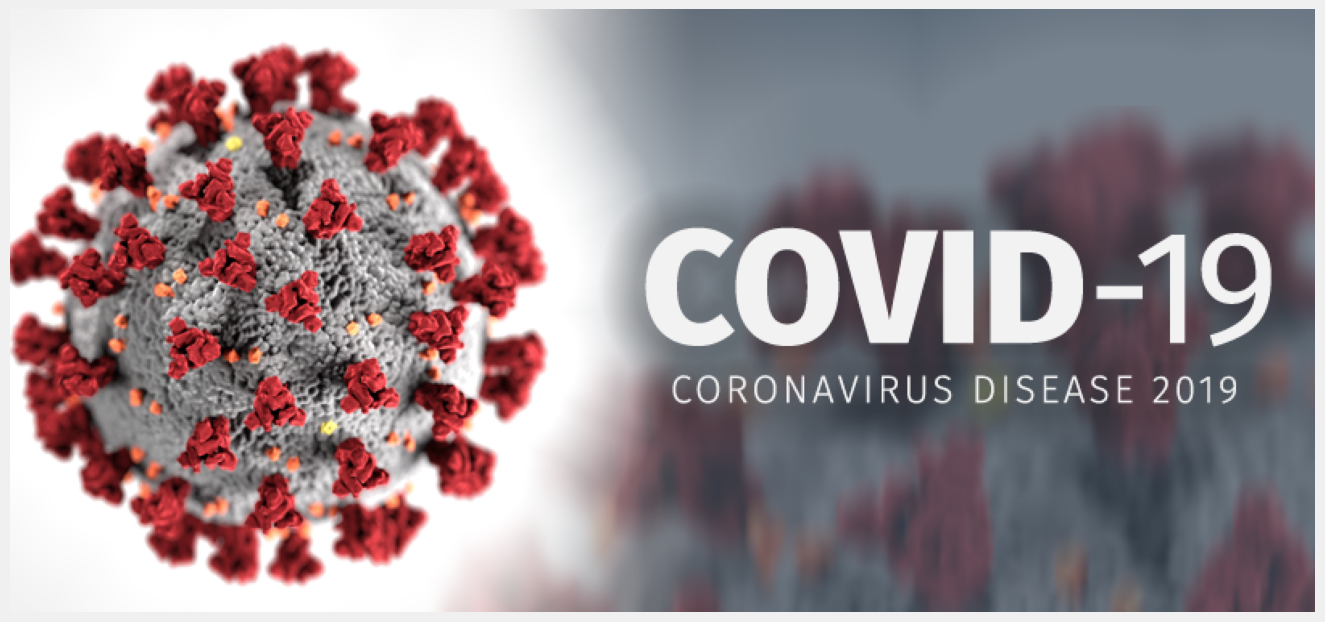

In [42]:
# @title
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    img = Image.open(filename)
    plt.figure(figsize=(15, 15))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


# 🦠 COVID-19 (COVID-19)

# What is it?

##A virus that causes a respiratory illness. Symptoms include fever, cough, and shortness of breath. It can range from mild to severe.

#When did it emerge?

##First reported in Wuhan, China, December 2019

##Declared a global pandemic by the World Health Organization in March 2020

##Number of infections and deaths (estimated):

##Confirmed infections: Approximately 780 million

#Deaths: Over 7.1 million

##Severity of the disease:

##It spreads rapidly from person to person.

##It can cause severe pneumonia and complications in the elderly or those with underlying health conditions.

##It has impacted health, the economy, and travel worldwide.

#Prevention methods:

##Wash your hands frequently.

##Wear a mask.

##ractice social distancing.

##Get vaccinated to reduce the risk of severe illness.

In [ ]:
# @title
pip install opendatasets

In [ ]:
# @title
import opendatasets as od
od.download("https://www.kaggle.com/datasets/pranavraikokte/covid19-image-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: amralqadi
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/pranavraikokte/covid19-image-dataset


100%|██████████| 158M/158M [00:00<00:00, 732MB/s]


In [ ]:
import pandas as pd
import numpy as np
import os
import cv2
import itertools
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam,Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

In [ ]:
folder_training = "/content/covid19-image-dataset/Covid19-dataset/train"
path_tr=[]
labels=[]

class_folders=os.listdir(folder_training)

for cls in class_folders:
    cls_path=os.path.join(folder_training,cls)

    if not os.path.isdir(cls_path):
        continue

    img_files=os.listdir(cls_path)

    for img in img_files:
        img_path=os.path.join(cls_path,img)

        path_tr.append(img_path)
        labels.append(cls)


df_train=pd.DataFrame({
    'Img_Path':path_tr,
    "Img_Label":labels
})

In [ ]:
df_train

,Img_Path,Img_Label
0,/content/covid19-image-dataset/Covid19-dataset...,Normal
1,/content/covid19-image-dataset/Covid19-dataset...,Normal
2,/content/covid19-image-dataset/Covid19-dataset...,Normal
3,/content/covid19-image-dataset/Covid19-dataset...,Normal
4,/content/covid19-image-dataset/Covid19-dataset...,Normal
...,...,...
246,/content/covid19-image-dataset/Covid19-dataset...,Covid
247,/content/covid19-image-dataset/Covid19-dataset...,Covid
248,/content/covid19-image-dataset/Covid19-dataset...,Covid
249,/content/covid19-image-dataset/Covid19-dataset...,Covid


In [ ]:
folder_test = r"/content/covid19-image-dataset/Covid19-dataset/test"

path_ts = []
Labels = []

class_folder_TS = os.listdir(folder_test)

for cls_TS in class_folder_TS:
    cls_path = os.path.join(folder_test, cls_TS)

    if not os.path.isdir(cls_path):
        continue

    img_files = os.listdir(cls_path)

    for img in img_files:
        img_path = os.path.join(cls_path, img)

        path_ts.append(img_path)
        Labels.append(cls_TS)

df_test = pd.DataFrame({
    "Img_Path": path_ts,
    "Img_Label": Labels
})


In [ ]:
df_test

,Img_Path,Img_Label
0,/content/covid19-image-dataset/Covid19-dataset...,Normal
1,/content/covid19-image-dataset/Covid19-dataset...,Normal
2,/content/covid19-image-dataset/Covid19-dataset...,Normal
3,/content/covid19-image-dataset/Covid19-dataset...,Normal
4,/content/covid19-image-dataset/Covid19-dataset...,Normal
...,...,...
61,/content/covid19-image-dataset/Covid19-dataset...,Covid
62,/content/covid19-image-dataset/Covid19-dataset...,Covid
63,/content/covid19-image-dataset/Covid19-dataset...,Covid
64,/content/covid19-image-dataset/Covid19-dataset...,Covid


In [ ]:
valid_df,test_df=train_test_split(df_test,train_size=0.5,shuffle=True,random_state=42)

In [ ]:
tr_gen = ImageDataGenerator(rescale=1./255)
ts_gen = ImageDataGenerator(rescale=1./255)

batch_size = 16
img_size = (224,224)
class_names = ['Covid', 'Normal', 'Viral Pneumonia']


# Train
train_generator = tr_gen.flow_from_dataframe(
    df_train,
    x_col="Img_Path",
    y_col="Img_Label",
    target_size=img_size,
    class_mode="categorical",
    color_mode="rgb",
    classes=class_names,
    shuffle=True,
    batch_size=batch_size
)

# Valid
valid_generator = ts_gen.flow_from_dataframe(
    valid_df,
    x_col="Img_Path",
    y_col="Img_Label",
    target_size=img_size,
    class_mode="categorical",
    color_mode="rgb",
    classes=class_names,
    shuffle=False,
    batch_size=batch_size
)

# Test
test_generator = ts_gen.flow_from_dataframe(
    df_test,
    x_col="Img_Path",
    y_col="Img_Label",
    target_size=img_size,
    class_mode="categorical",
    color_mode="rgb",
    classes=class_names,
    shuffle=False,
    batch_size=batch_size
)

Found 251 validated image filenames belonging to 3 classes.
Found 33 validated image filenames belonging to 3 classes.
Found 66 validated image filenames belonging to 3 classes.


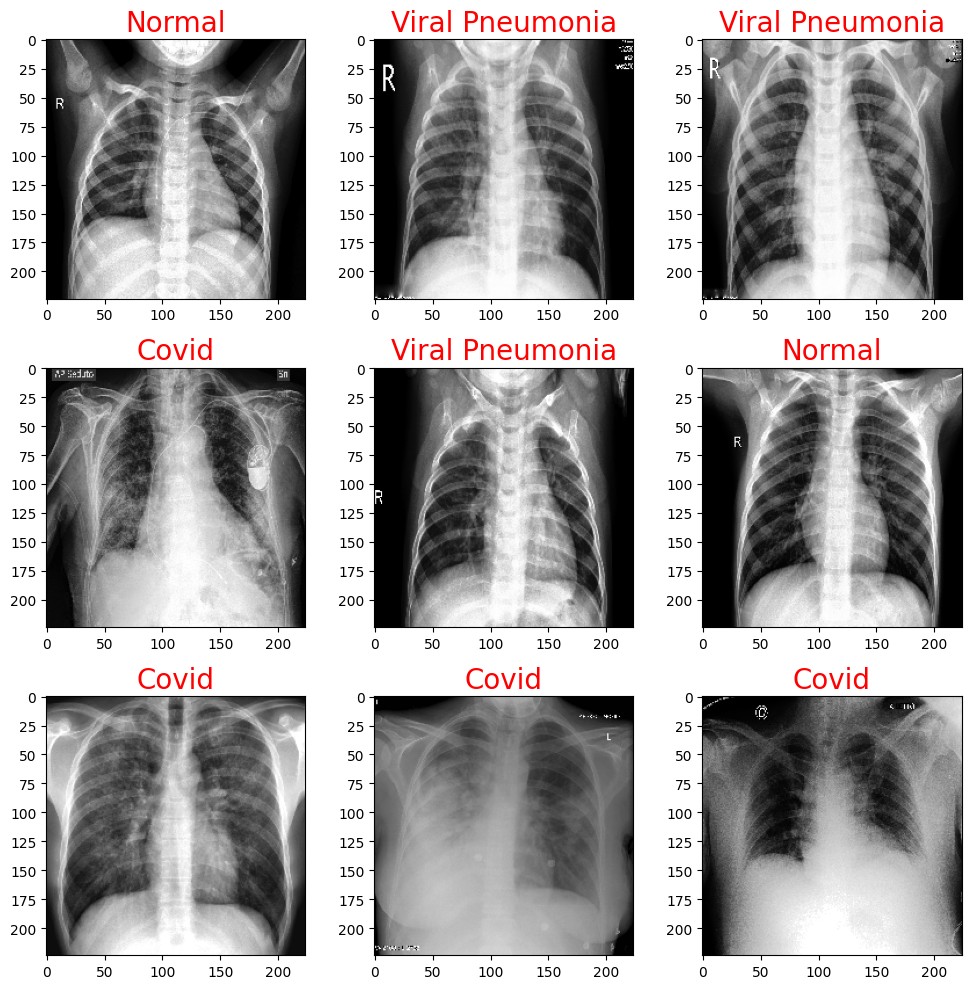

In [ ]:
gen_dict=train_generator.class_indices

classes=list(gen_dict.keys())

images,labels=next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)

    image=images[i]

    plt.imshow(image)

    index=np.argmax(labels[i])
    class_name=classes[index]

    plt.title(class_name,color="red",fontsize=20)

plt.tight_layout()
plt.show()

Saving 1712342077540.jpg to 1712342077540 (2).jpg


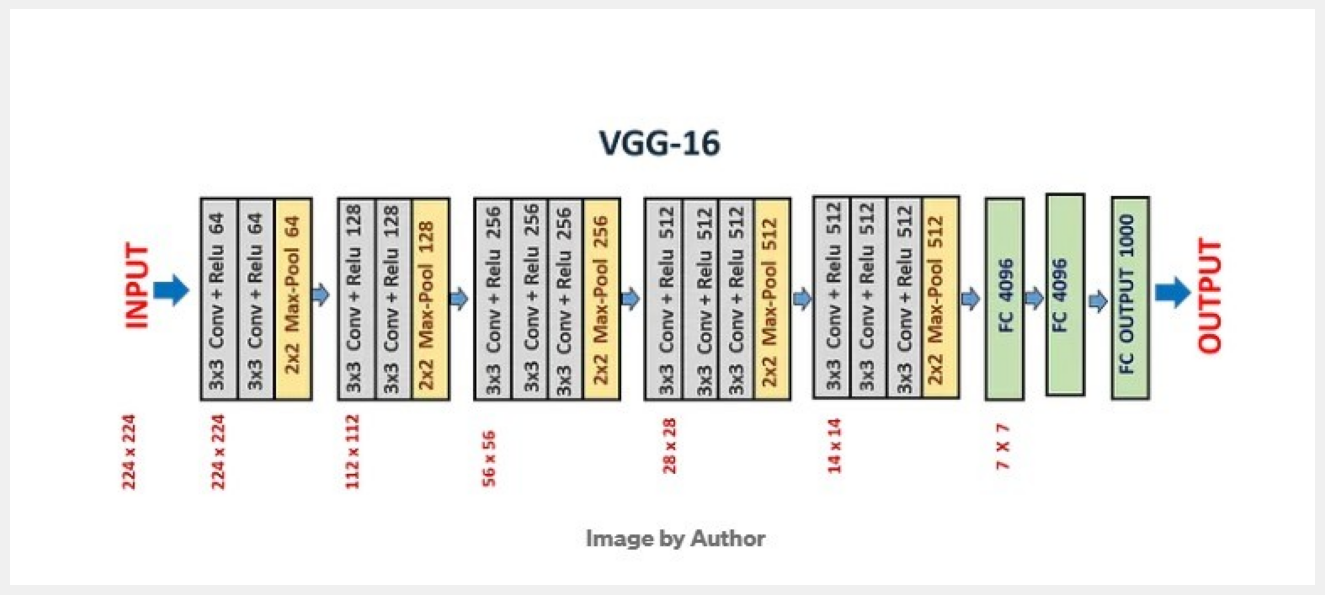

In [ ]:
# @title
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    img = Image.open(filename)
    plt.figure(figsize=(15, 15))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

## VGG was developed in 2014 by the Visual Geometry Group at Oxford University. Its goal was to demonstrate the power of deep networks using small 3x3 filters.

## Key points: Simple design, high depth (16–19 layers), strong results on ImageNet, excellent for feature extraction and transfer learning.

## Weaknesses: Huge number of parameters (~138 million), slow training, requires a powerful GPU and a lot of memory.

In [ ]:
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

class_count = 3# to define number of classes in dense layer

model = Sequential([
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu", input_shape= img_shape),
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(256,activation = "relu"),
    Dense(64,activation = "relu"),
    Dense(class_count, activation = "softmax")
])

model.compile(Adamax(learning_rate= 0.0003), loss= 'categorical_crossentropy', metrics= ['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,154,115 (80.70 MB)

 Trainable params: 21,154,115 (80.70 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    EarlyStopping(
        patience=3,
        restore_best_weights=True,

    ),
    ReduceLROnPlateau(
        patience=3,
        factor=0.5,

    )
]


In [ ]:
epochs=30
history=model.fit(train_generator,epochs=epochs,validation_data=valid_generator, shuffle= False)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.4086 - loss: 1.1012 - val_accuracy: 0.3636 - val_loss: 1.0948
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 517ms/step - accuracy: 0.4474 - loss: 1.0862 - val_accuracy: 0.3636 - val_loss: 1.0695
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 391ms/step - accuracy: 0.4587 - loss: 0.9820 - val_accuracy: 0.6970 - val_loss: 0.5873
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 433ms/step - accuracy: 0.8607 - loss: 0.3589 - val_accuracy: 0.7879 - val_loss: 0.4498
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 401ms/step - accuracy: 0.8599 - loss: 0.4168 - val_accuracy: 0.6970 - val_loss: 0.4690
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 414ms/step - accuracy: 0.9126 - loss: 0.2599 - val_accuracy: 0.7879 - val_loss: 0.3624
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 407ms/step - accuracy: 0.9112 - loss: 0.2171 - val_accuracy: 0.8485 - val_loss: 0.2858
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 405ms/step - accuracy: 0.9389 - loss: 0.1931 - val_accuracy: 0.84

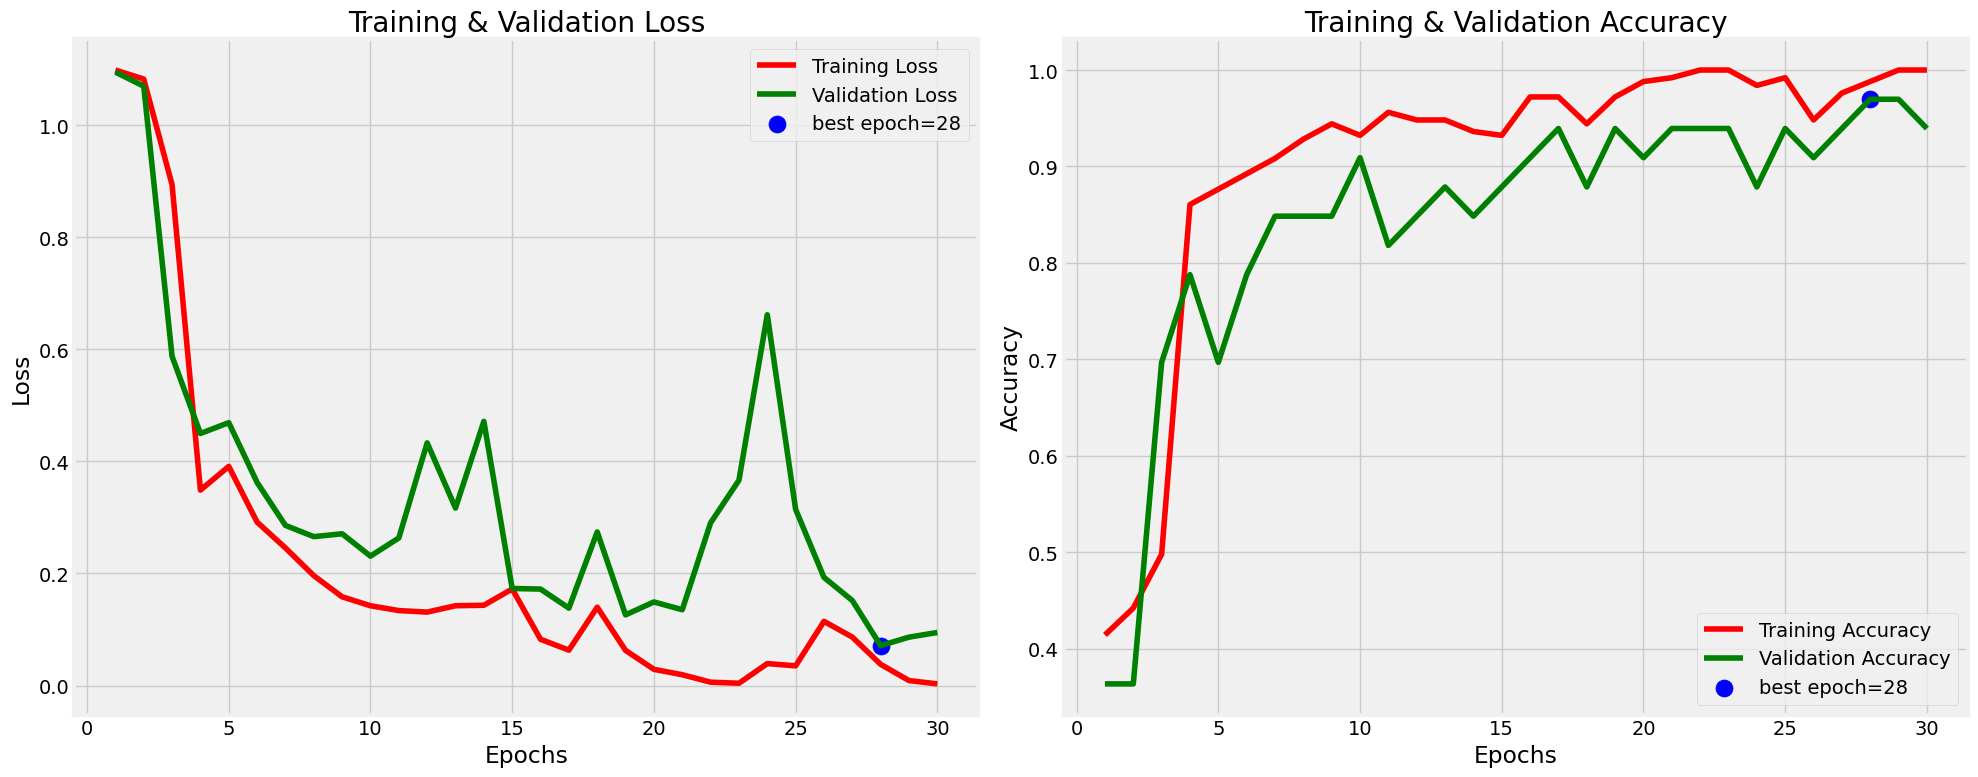

In [ ]:
tr_acc = history.history["accuracy"]
tr_loss = history.history["loss"]
val_acc = history.history["val_accuracy"]
val_loss = history.history["val_loss"]

# Best epochs
index_loss = np.argmin(val_loss)      # أقل Loss
index_acc  = np.argmax(val_acc)       # أعلى Accuracy

epochs = [i + 1 for i in range(len(tr_acc))]

loss_label = f"best epoch={index_loss + 1}"
acc_label  = f"best epoch={index_acc + 1}"

# Plot
plt.figure(figsize=(20, 8))
plt.style.use("fivethirtyeight")

# LOSS
plt.subplot(1, 2, 1)
plt.plot(epochs, tr_loss, "r", label="Training Loss")
plt.plot(epochs, val_loss, "g", label="Validation Loss")
plt.scatter(index_loss + 1, val_loss[index_loss],
            s=150, c="blue", label=loss_label)
plt.title("Training & Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# ACCURACY
plt.subplot(1, 2, 2)
plt.plot(epochs, tr_acc, "r", label="Training Accuracy")
plt.plot(epochs, val_acc, "g", label="Validation Accuracy")
plt.scatter(index_acc + 1, val_acc[index_acc],
            s=150, c="blue", label=acc_label)
plt.title("Training & Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
train_score = model.evaluate(train_generator, verbose= 1)
valid_score = model.evaluate(valid_generator, verbose= 1)
test_score = model.evaluate(test_generator, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 898ms/step - accuracy: 1.0000 - loss: 0.0010   
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.9384 - loss: 0.0856


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 881ms/step - accuracy: 0.8865 - loss: 0.5442
Train Loss:  0.0013525791000574827
Train Accuracy:  1.0
--------------------
Validation Loss:  0.09466231614351273
Validation Accuracy:  0.939393937587738
--------------------
Test Loss:  0.5484330058097839
Test Accuracy:  0.8939393758773804


In [ ]:
preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 253ms/step


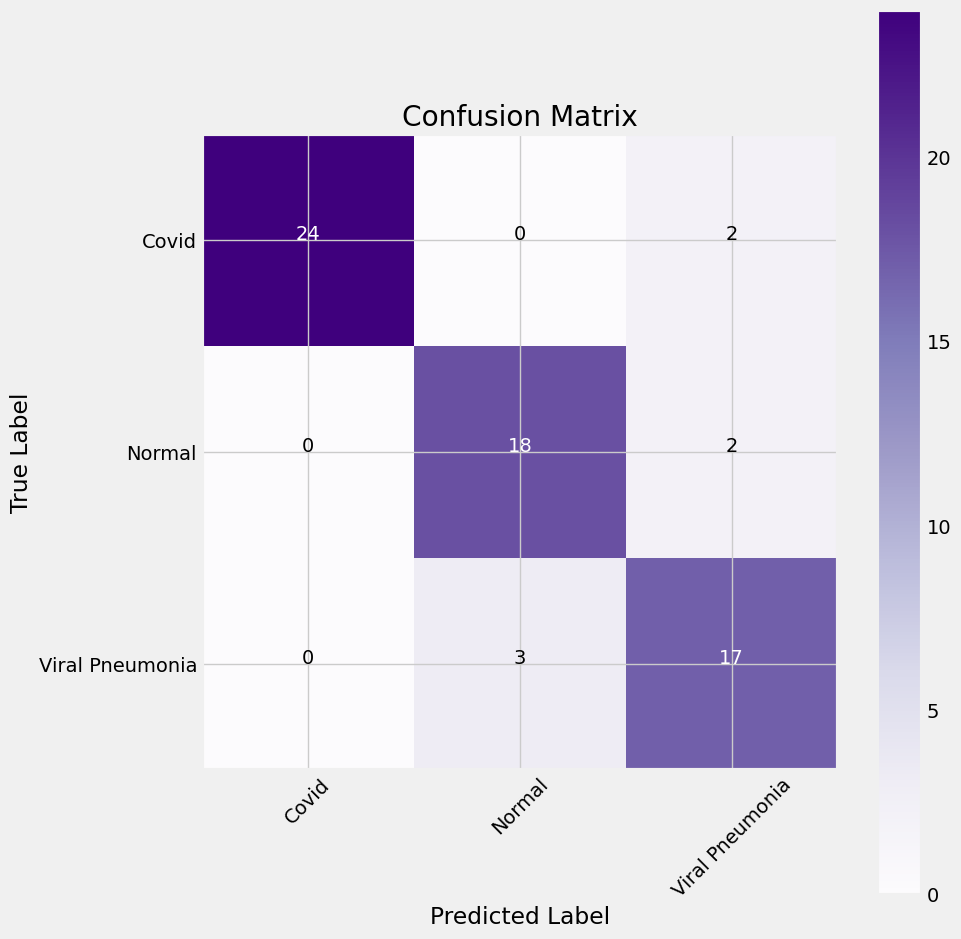

In [ ]:
# Generate the class labels
gen_dict = train_generator.class_indices
classes = list(gen_dict.keys())

# Compute the confusion matrix
cm = confusion_matrix(test_generator.classes, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap='Purples')  # Use red colormap
plt.title('Confusion Matrix')
plt.colorbar()

# Set tick marks and labels
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Add text annotations
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()  # Adjust subplots to fit into the figure area
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [ ]:
print(classification_report(test_generator.classes, y_pred, target_names= classes))

                 precision    recall  f1-score   support

          Covid       1.00      0.92      0.96        26
         Normal       0.86      0.90      0.88        20
Viral Pneumonia       0.81      0.85      0.83        20

       accuracy                           0.89        66
      macro avg       0.89      0.89      0.89        66
   weighted avg       0.90      0.89      0.90        66



In [ ]:
model.save("Coved 19 Classifier.h5")

In [ ]:
!ls /content
print(train_generator.class_indices)

In [ ]:
# Load model
loaded_model = tf.keras.models.load_model("/content/Coved 19 Classifier.h5", compile=False)
loaded_model.compile(Adamax(learning_rate=0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

# Correct class order
class_labels = list(train_generator.class_indices.keys())
print("Class order:", class_labels)

# Load image
image_path = "/content/covid19-image-dataset/Covid19-dataset/test/Viral Pneumonia/0101.jpeg"
image = Image.open(image_path)

# Preprocess
img = image.resize((224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)


# Predict
pred = loaded_model.predict(img_array)

print("Predicted:", class_labels[np.argmax(pred)])


Class order: ['Covid', 'Normal', 'Viral Pneumonia']


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted: Viral Pneumonia


Saving 1_C8jf92MeHZnxnbpMkz6jkQ.png to 1_C8jf92MeHZnxnbpMkz6jkQ.png


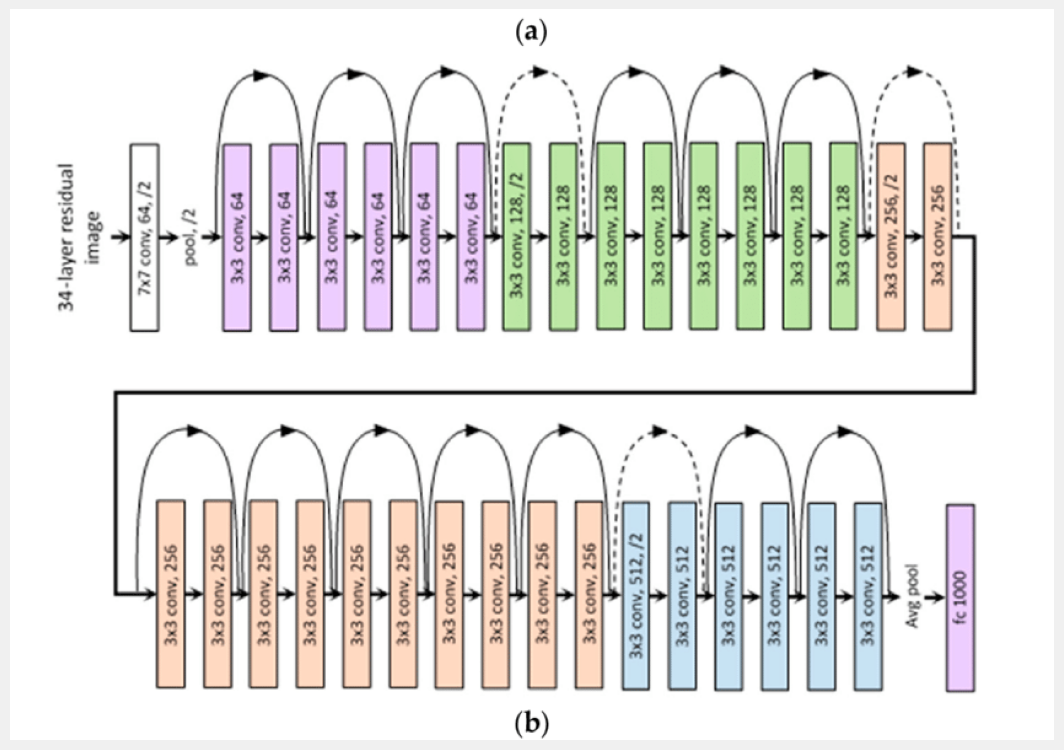

In [ ]:
# @title
uploaded = files.upload()

for filename in uploaded.keys():
    img = Image.open(filename)
    plt.figure(figsize=(15, 15))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

## ResNet was developed in 2015 by Microsoft's Deep Learning team. Its goal is  to address performance degradation in very deep networks using residual blocks.

## Key points: It utilizes residual connections to facilitate training on very deep networks (50–152 layers), offers excellent performance on ImageNet, and has become a foundation for transfer learning.

## Weaknesses: It is somewhat more complex in design compared to VGG, and some deep versions require very high computational resources.

In [ ]:
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

In [ ]:
# Base Model
base_model=ResNet101(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3))

base_model.trainable=False



model_RS = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(class_count, activation="softmax")
])


#Compile
model_RS.compile(optimizer=Adamax(learning_rate=0.0003),
                 loss="categorical_crossentropy",
                 metrics=["accuracy"]
                 )




171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
#Summary
model_RS.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet101 (Functional)          │ (None, 7, 7, 2048)     │    42,658,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,920,835 (163.73 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 42,658,176 (162.73 MB)

In [ ]:
#Train
epochs=20
history=model_RS.fit(
    train_generator,
    epochs=epochs,
    validation_data=valid_generator,
    shuffle=False
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.3685 - loss: 1.2687 - val_accuracy: 0.4545 - val_loss: 1.0387
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 397ms/step - accuracy: 0.3911 - loss: 1.1363 - val_accuracy: 0.5152 - val_loss: 1.0032
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 322ms/step - accuracy: 0.3991 - loss: 1.1008 - val_accuracy: 0.5152 - val_loss: 0.9876
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 399ms/step - accuracy: 0.4856 - loss: 1.0283 - val_accuracy: 0.5455 - val_loss: 0.9511
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 338ms/step - accuracy: 0.5829 - loss: 0.9354 - val_accuracy: 0.5758 - val_loss: 0.9368
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 382ms/step - accuracy: 0.5086 - loss: 0.9910 - val_accuracy: 0.5455 - val_loss: 0.9169
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 336ms/step - accuracy: 0.6273 - loss: 0.8961 - val_accuracy: 0.5152 - val_loss: 0.8986
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 343ms/step - accuracy: 0.5548 - loss: 0.9355 - val_accuracy: 0.57

In [ ]:
train_score = model_RS.evaluate(train_generator, verbose= 1)
valid_score = model_RS.evaluate(valid_generator, verbose= 1)
test_score = model_RS.evaluate(test_generator, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 548ms/step - accuracy: 0.6793 - loss: 0.7487
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.5535 - loss: 0.7678
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6726 - loss: 0.7417
Train Loss:  0.7268285751342773
Train Accuracy:  0.6932271122932434
--------------------
Validation Loss:  0.7514917254447937
Validation Accuracy:  0.5757575631141663
--------------------
Test Loss:  0.6970344185829163
Test Accuracy:  0.6818181872367859


In [ ]:

preds_rs = model_RS.predict(test_generator)
y_pred_rs = np.argmax(preds_rs, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step


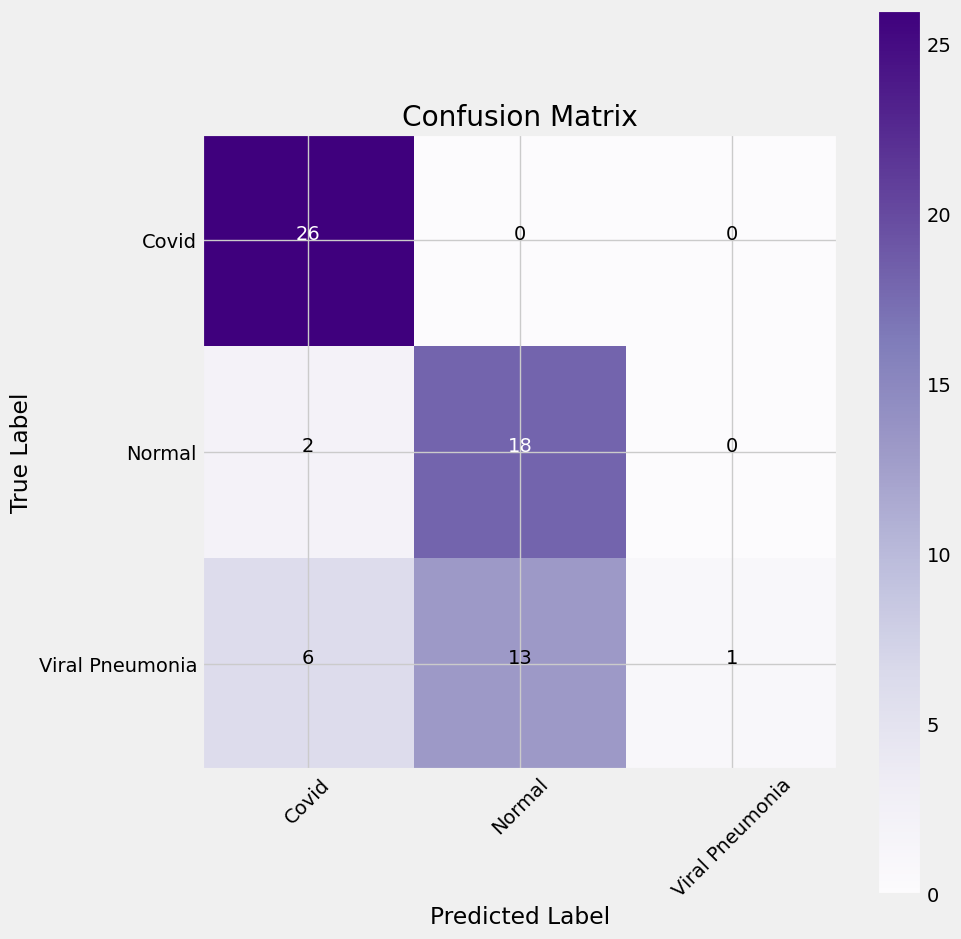

In [ ]:
# Generate the class labels
g_dict = test_generator.class_indices
classes = list(g_dict.keys())

# Compute the confusion matrix
cm = confusion_matrix(test_generator.classes, y_pred_rs)

# Plot confusion matrix
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap='Purples')  # Use red colormap
plt.title('Confusion Matrix')
plt.colorbar()

# Set tick marks and labels
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Add text annotations
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()  # Adjust subplots to fit into the figure area
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

## I wasn't concerned with the accuracy for ResNet here because that wasn't my target, but ResNet is a very, very heavy model.